In [8]:
import matplotlib.pyplot as plt
import os
from rdkit import Chem
from rdkit.Chem import rdmolops, rdmolfiles
from rdkit import RDPaths
 
import dgl
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
# from dgl import model_zoo
from dgllife.model import AttentiveFPPredictor
from dgllife.utils import mol_to_complete_graph, mol_to_bigraph
from dgllife.utils import atom_type_one_hot
from dgllife.utils import atom_degree_one_hot
from dgllife.utils import atom_formal_charge
from dgllife.utils import atom_num_radical_electrons
from dgllife.utils import atom_hybridization_one_hot
from dgllife.utils import atom_total_num_H_one_hot
from dgllife.utils import one_hot_encoding
from dgllife.utils import CanonicalAtomFeaturizer
from dgllife.utils import CanonicalBondFeaturizer
from dgllife.utils import ConcatFeaturizer
from dgllife.utils import BaseAtomFeaturizer
from dgllife.utils import BaseBondFeaturizer
from dgllife.utils import one_hot_encoding 
from dgl.data.utils import split_dataset
 
from functools import partial
from sklearn.metrics import roc_auc_score

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


In [9]:
model = AttentiveFPPredictor(node_feat_size=39,
                                  edge_feat_size=10,
                                  num_layers=2,
                                  num_timesteps=2,
                                  graph_feat_size=200,
                                  n_tasks=1,
                                  dropout=0.2)

In [12]:
def chirality(atom):
    try:
        return one_hot_encoding(atom.GetProp('_CIPCode'), ['R', 'S']) + \
               [atom.HasProp('_ChiralityPossible')]
    except:
        return [False, False] + [atom.HasProp('_ChiralityPossible')]
     
def collate_molgraphs(data):
    """Batching a list of datapoints for dataloader.
    Parameters
    ----------
    data : list of 3-tuples or 4-tuples.
        Each tuple is for a single datapoint, consisting of
        a SMILES, a DGLGraph, all-task labels and optionally
        a binary mask indicating the existence of labels.
    Returns
    -------
    smiles : list
        List of smiles
    bg : BatchedDGLGraph
        Batched DGLGraphs
    labels : Tensor of dtype float32 and shape (B, T)
        Batched datapoint labels. B is len(data) and
        T is the number of total tasks.
    masks : Tensor of dtype float32 and shape (B, T)
        Batched datapoint binary mask, indicating the
        existence of labels. If binary masks are not
        provided, return a tensor with ones.
    """
    assert len(data[0]) in [3, 4], \
        'Expect the tuple to be of length 3 or 4, got {:d}'.format(len(data[0]))
    if len(data[0]) == 3:
        smiles, graphs, labels = map(list, zip(*data))
        masks = None
    else:
        smiles, graphs, labels, masks = map(list, zip(*data))
 
    bg = dgl.batch(graphs)
    bg.set_n_initializer(dgl.init.zero_initializer)
    bg.set_e_initializer(dgl.init.zero_initializer)
    labels = torch.stack(labels, dim=0)
     
    if masks is None:
        masks = torch.ones(labels.shape)
    else:
        masks = torch.stack(masks, dim=0)
    return smiles, bg, labels, masks
 
atom_featurizer = BaseAtomFeaturizer(
                 {'hv': ConcatFeaturizer([
                  partial(atom_type_one_hot, allowable_set=[
                          'B', 'C', 'N', 'O', 'F', 'Si', 'P', 'S', 'Cl', 'As', 'Se', 'Br', 'Te', 'I', 'At'],
                    encode_unknown=True),
                  partial(atom_degree_one_hot, allowable_set=list(range(6))),
                  atom_formal_charge, atom_num_radical_electrons,
                  partial(atom_hybridization_one_hot, encode_unknown=True),
                  lambda atom: [0], # A placeholder for aromatic information,
                    atom_total_num_H_one_hot, chirality
                 ],
                )})
bond_featurizer = BaseBondFeaturizer({
                                     'he': lambda bond: [0 for _ in range(10)]
    })
 
train='solubility.train.sdf'
test='solubility.test.sdf'

train_mols = Chem.SDMolSupplier(train)
train_smi =[Chem.MolToSmiles(m) for m in train_mols]
train_sol = torch.tensor([float(mol.GetProp('SOL')) for mol in train_mols]).reshape(-1,1)

test_mols =  Chem.SDMolSupplier(test)
test_smi = [Chem.MolToSmiles(m) for m in test_mols]
test_sol = torch.tensor([float(mol.GetProp('SOL')) for mol in test_mols]).reshape(-1,1)

train_graph =[mol_to_bigraph(mol,
                           node_featurizer=atom_featurizer, 
                           edge_featurizer=bond_featurizer) for mol in train_mols]
 
test_graph =[mol_to_bigraph(mol,
                           node_featurizer=atom_featurizer, 
                           edge_featurizer=bond_featurizer) for mol in test_mols]
 
def run_a_train_epoch(n_epochs, epoch, model, data_loader,loss_criterion, optimizer):
    model.train()
    total_loss = 0
    losses = []
     
    for batch_id, batch_data in enumerate(data_loader):
        batch_data
        smiles, bg, labels, masks = batch_data
        if torch.cuda.is_available():
            bg = bg.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
         
        prediction = model(bg, bg.ndata['hv'], bg.edata['he'])
        loss = (loss_criterion(prediction, labels)*(masks != 0).float()).mean()
        #loss = loss_criterion(prediction, labels)
        #print(loss.shape)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        losses.append(loss.data.item())
         
    #total_score = np.mean(train_meter.compute_metric('rmse'))
    total_score = np.mean(losses)
    print('epoch {:d}/{:d}, training {:.4f}'.format( epoch + 1, n_epochs,  total_score))
    return total_score


In [13]:
model = AttentiveFPPredictor(node_feat_size=39,
                                  edge_feat_size=10,
                                  num_layers=2,
                                  num_timesteps=2,
                                  graph_feat_size=200,
                                  n_tasks=1,
                                  dropout=0.2)
model = model.to(device)
 
train_loader = DataLoader(dataset=list(zip(train_smi, train_graph, train_sol)), batch_size=128, collate_fn=collate_molgraphs)
test_loader = DataLoader(dataset=list(zip(test_smi, test_graph, test_sol)), batch_size=128, collate_fn=collate_molgraphs)
 
loss_fn = nn.MSELoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=10 ** (-2.5), weight_decay=10 ** (-5.0),)
n_epochs = 100
epochs = []
scores = []
for e in range(n_epochs):
    score = run_a_train_epoch(n_epochs, e, model, train_loader, loss_fn, optimizer)
    epochs.append(e)
    scores.append(score)
model.eval()

epoch 1/100, training 8.7777
epoch 2/100, training 4.6703
epoch 3/100, training 3.1460
epoch 4/100, training 3.0195
epoch 5/100, training 2.8313
epoch 6/100, training 2.4810
epoch 7/100, training 1.7507
epoch 8/100, training 1.5902
epoch 9/100, training 1.7516
epoch 10/100, training 1.0229
epoch 11/100, training 1.0342
epoch 12/100, training 0.9760
epoch 13/100, training 0.8219
epoch 14/100, training 0.7387
epoch 15/100, training 0.7632
epoch 16/100, training 0.6852
epoch 17/100, training 0.7779
epoch 18/100, training 0.8465
epoch 19/100, training 0.6160
epoch 20/100, training 0.6436
epoch 21/100, training 0.6744
epoch 22/100, training 0.5831
epoch 23/100, training 0.7449
epoch 24/100, training 0.9836
epoch 25/100, training 0.7288
epoch 26/100, training 0.7027
epoch 27/100, training 0.5113
epoch 28/100, training 0.4988
epoch 29/100, training 0.4381
epoch 30/100, training 0.4635
epoch 31/100, training 0.4397
epoch 32/100, training 0.4229
epoch 33/100, training 0.4959
epoch 34/100, train

AttentiveFPPredictor(
  (gnn): AttentiveFPGNN(
    (init_context): GetContext(
      (project_node): Sequential(
        (0): Linear(in_features=39, out_features=200, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
      )
      (project_edge1): Sequential(
        (0): Linear(in_features=49, out_features=200, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
      )
      (project_edge2): Sequential(
        (0): Dropout(p=0.2, inplace=False)
        (1): Linear(in_features=400, out_features=1, bias=True)
        (2): LeakyReLU(negative_slope=0.01)
      )
      (attentive_gru): AttentiveGRU1(
        (edge_transform): Sequential(
          (0): Dropout(p=0.2, inplace=False)
          (1): Linear(in_features=200, out_features=200, bias=True)
        )
        (gru): GRUCell(200, 200)
      )
    )
    (gnn_layers): ModuleList(
      (0): GNNLayer(
        (project_edge): Sequential(
          (0): Dropout(p=0.2, inplace=False)
          (1): Linear(in_features=400, out_fea

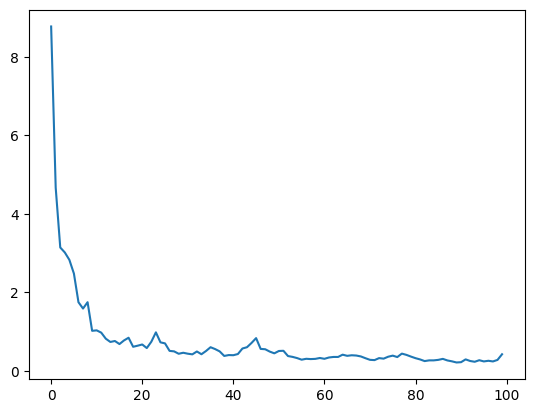

In [14]:
plt.plot(epochs, scores)

In [15]:
import copy
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
from IPython.display import display
import matplotlib
import matplotlib.cm as cm

In [20]:
def drawmol(idx, dataset, timestep):
    smiles, graph, _ = dataset[idx]
    print(smiles)
    bg = dgl.batch([graph])
    atom_feats, bond_feats = bg.ndata['hv'], bg.edata['he']
    if torch.cuda.is_available():
        print('use cuda')
        bg = bg.to(torch.device('cuda:0'))
        atom_feats = atom_feats.to('cuda:0')
        bond_feats = bond_feats.to('cuda:0')
    
    _, atom_weights = model(bg, atom_feats, bond_feats, get_node_weight=True)
    assert timestep < len(atom_weights), 'Unexpected id for the readout round'
    atom_weights = atom_weights[timestep]
    min_value = torch.min(atom_weights)
    max_value = torch.max(atom_weights)
    atom_weights = (atom_weights - min_value) / (max_value - min_value)
    
    norm = matplotlib.colors.Normalize(vmin=0, vmax=1.28)
    cmap = cm.get_cmap('bwr')
    plt_colors = cm.ScalarMappable(norm=norm, cmap=cmap)
    atom_colors = {i: plt_colors.to_rgba(atom_weights[i].data.item()) for i in range(bg.number_of_nodes())}
    
    mol = Chem.MolFromSmiles(smiles)
    rdDepictor.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DSVG(280, 280)
    drawer.SetFontSize(1)
    op = drawer.drawOptions()
    
    mol = rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(mol, highlightAtoms=range(bg.number_of_nodes()),
                             highlightBonds=[],
                             highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    svg = svg.replace('svg:', '')
    if torch.cuda.is_available():
        atom_weights = atom_weights.to('cpu')
        
    a = np.array([[0,1]])
    plt.figure(figsize=(9, 1.5))
    img = plt.imshow(a, cmap="bwr")
    plt.gca().set_visible(False)
    cax = plt.axes([0.1, 0.2, 0.8, 0.2])
    plt.colorbar(orientation='horizontal', cax=cax)
    plt.show()
    return (Chem.MolFromSmiles(smiles), atom_weights.data.numpy(), svg)

In [23]:
atom_weights

NameError: name 'atom_weights' is not defined

In [21]:
target = test_loader.dataset

0
CCC(C)CC
use cuda


/tmp/ipykernel_3821252/1527596816.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('bwr')


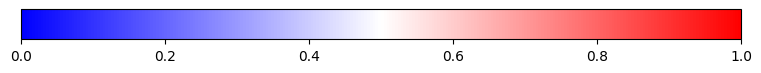

0.0 1.0


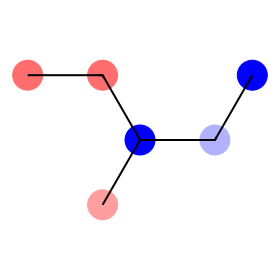

1
CC(C)CC(C)C
use cuda


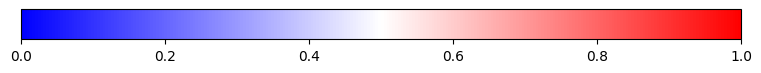

0.0 1.0


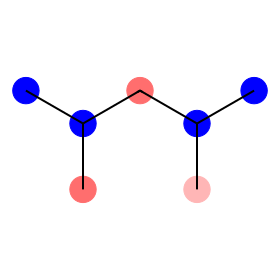

2
C=CCCC
use cuda


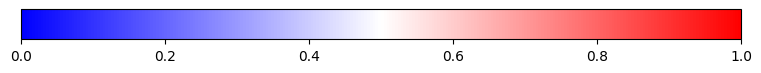

0.0 1.0


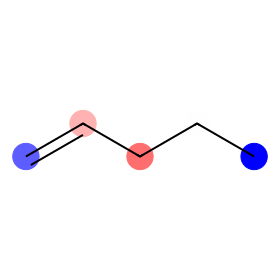

3
C1=CCCCC1
use cuda


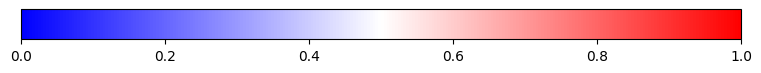

0.0 1.0


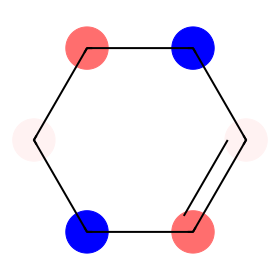

4
C=CCC=C
use cuda


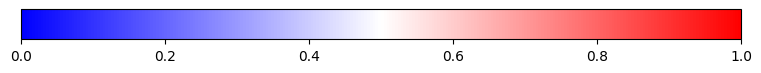

0.0 1.0


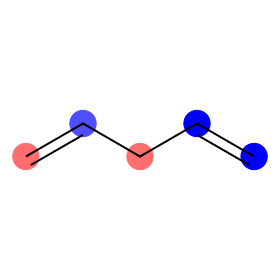

In [22]:
for i in range(len(target))[:5]:
    print(i)
    mol, aw, svg = drawmol(i, target, 0)
    print(aw.min(), aw.max())
    display(SVG(svg))